<a href="https://colab.research.google.com/github/alansiny/INTERSHIP-AI-ML/blob/main/twitter_tweet_posorneg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import kagglehub

path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:",path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [ ]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis"
)

print("Dataset path:", path)

# List files in dataset folder
print(os.listdir(path))

# Convert training file to CSV
train_file = os.path.join(path, "twitter_training.csv")

df = pd.read_csv(train_file, header=None)

output_csv = "twitter_training_converted.csv"
df.to_csv(output_csv, index=False)

print("CSV saved as:", output_csv)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Dataset path: /kaggle/input/twitter-entity-sentiment-analysis
['twitter_validation.csv', 'twitter_training.csv']
CSV saved as: twitter_training_converted.csv


In [ ]:
import os

for file in os.listdir(path):
    print(file)

twitter_validation.csv
twitter_training.csv


In [ ]:
import pandas as pd

# Read CSV file
df = pd.read_csv("twitter_training_converted.csv")

# Print first 10 rows
print(df.head(10))

      0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   
5  2401  Borderlands  Positive   
6  2402  Borderlands  Positive   
7  2402  Borderlands  Positive   
8  2402  Borderlands  Positive   
9  2402  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
5  im getting into borderlands and i can murder y...  
6  So I spent a few hours making something for fu...  
7  So I spent a couple of hours doing something f...  
8  So I spent a few hours doing something for fun...  
9  So I spent a few hours making something for fu...  


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
cols = ["ID", "Entity", "Sentiment", "Tweet"]

df = pd.read_csv(
    "/kaggle/input/twitter-entity-sentiment-analysis/twitter_training.csv",
    names=cols
)

df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [ ]:
print(df.isnull().sum())

ID             0
Entity         0
Sentiment      0
Tweet        686
dtype: int64


In [ ]:
df["Tweet"] = df["Tweet"].fillna("Unknown")

df["Entity"] = df["Entity"].fillna(
    df["Entity"].mode()[0]
)

In [ ]:
print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (74682, 4)
After: (71982, 4)


In [ ]:
le = LabelEncoder()

df["Sentiment"] = le.fit_transform(
    df["Sentiment"]
)

df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,3,im getting on borderlands and i will murder yo...
1,2401,Borderlands,3,I am coming to the borders and I will kill you...
2,2401,Borderlands,3,im getting on borderlands and i will kill you ...
3,2401,Borderlands,3,im coming on borderlands and i will murder you...
4,2401,Borderlands,3,im getting on borderlands 2 and i will murder ...


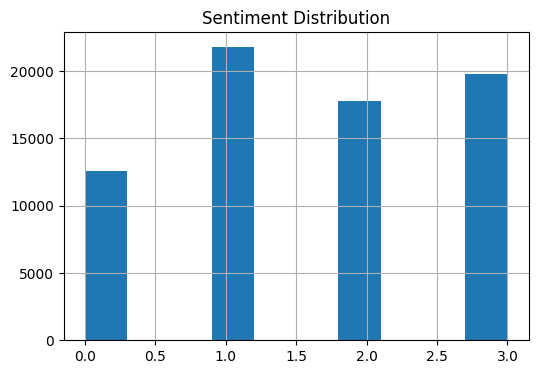

In [ ]:
plt.figure(figsize=(6,4))

df["Sentiment"].hist()

plt.title("Sentiment Distribution")
plt.show()

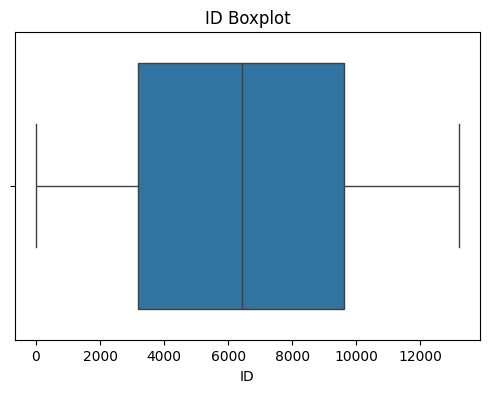

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["ID"])

plt.title("ID Boxplot")
plt.show()

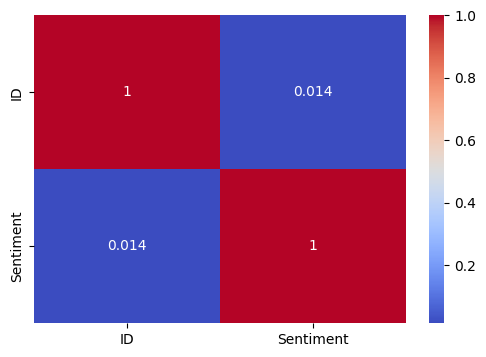

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[["ID","Sentiment"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
print(df["ID"].skew())

0.030409502418494074


In [ ]:
df["ID"] = np.log1p(df["ID"])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_text = tfidf.fit_transform(
    df["Tweet"]
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_text = tfidf.fit_transform(
    df["Tweet"]
)

In [ ]:
y = df["Sentiment"]

In [ ]:
y = df["Sentiment"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred_lr))

print(classification_report(
    y_test,
    pred_lr
))

Accuracy: 0.6952837396679864
              precision    recall  f1-score   support

           0       0.69      0.54      0.60      2521
           1       0.73      0.78      0.75      4277
           2       0.69      0.64      0.66      3594
           3       0.67      0.75      0.71      4005

    accuracy                           0.70     14397
   macro avg       0.69      0.68      0.68     14397
weighted avg       0.69      0.70      0.69     14397



In [ ]:
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_dense, y_train)

pred_rf = rf.predict(X_test_dense)

print("Accuracy:",
      accuracy_score(y_test, pred_rf))

print(classification_report(
    y_test,
    pred_rf
))

In [25]:
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ('tfidf',
     TfidfVectorizer(max_features=5000)),
    ('clf',
     LogisticRegression(max_iter=1000))
])

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Tweet"],
    y,
    test_size=0.2,
    random_state=42
)

pipe_lr.fit(X_train_text, y_train)

pred = pipe_lr.predict(X_test_text)

print(
    accuracy_score(y_test, pred)
)

0.6922275474057096


In [27]:
pipe_rf = Pipeline([
    ('tfidf',
     TfidfVectorizer(max_features=3000)),
    ('rf',
     RandomForestClassifier(
         n_estimators=100,
         random_state=42
     ))
])

pipe_rf.fit(X_train_text, y_train)

pred = pipe_rf.predict(X_test_text)

print(
    accuracy_score(y_test, pred)
)

0.882544974647496


In [28]:
results = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.695284
1        Random Forest  0.890672


In [29]:
tweet =input("Enter a tweet: ")
pred_lr = pipe_lr.predict([tweet])
sentiment_lr=le.inverse_transform(pred_lr)[0]

pred_lr = pipe_rf.predict([tweet])
sentiment_rf=le.inverse_transform(pred_lr)[0]
print("\nResults")
print("Logistic Regression:", sentiment_lr)
print("Random Forest:", sentiment_rf)


Enter a tweet: this is a good game

Results
Logistic Regression: Positive
Random Forest: Positive
